The previus experiment was to train the models to be able to identify wether if the tumor was malign or bening. The new part of this Thesis is to try and identify the 8 types of tumors present in this dataset.

As always, the first step is to mount google drive.

In [1]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Google drive mount (it is only needed once, but it is better to include it)
drive.mount('/content/drive')
print("Google Drive connected sucessfully. Eeverything is ready for a Patient-level split.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected sucessfully. Eeverything is ready for a Patient-level split.


The dataset is splitted by patients to avoid overfitting

In [1]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

def get_patient_id(filename):
    """
    Extracts a unique patient ID from the filename.
    Assumes format like: SOB_B_A-14-22549AB-40-001.png -> '14-22549AB'
    """
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_patient_split_multiclass(origin_path, final_path='/content/data_split', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    # 1. Detect zoom folders (100X, 200X, 400X, 40X)
    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        # Detect the 8 tumor classes dynamically
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]

        # Dictionary to store all patients per class
        # patients_dict['adenosis']['14-22549AB'] = [img1, img2...]
        patients_dict = {c: {} for c in classes}

        # Group images by patient ID for each class
        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        # Skip if directory is empty or classes are missing
        if not classes or any(not patients_dict[c] for c in classes):
            print(f"Skipping zoom {amp} due to missing data.")
            continue

        # 2. Balance: Find the minimum number of patients across all 8 classes
        min_patients = min(len(patients_dict[c]) for c in classes)

        # 3. Process and split each class
        amp_train_count, amp_test_count = 0, 0

        for c in classes:
            # Randomly sample patients to balance the classes
            sampled_patients = random.sample(list(patients_dict[c].keys()), min_patients)

            # Split patients (not images) into Train and Test
            train_p, test_p = train_test_split(sampled_patients, train_size=train_size, random_state=seed)

            # Create hermetic destination folders
            train_dest = final_p / 'train' / c
            test_dest = final_p / 'test' / c
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            # Copy files adding zoom prefix to avoid name collisions
            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")
                    amp_train_count += 1

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")
                    amp_test_count += 1

        print(f" Zoom {amp} processed (Multiclass Patient-Level Split):")
        print(f"   - Patients per class: {min_patients}")
        print(f"   - Images added to TRAIN: {amp_train_count}")
        print(f"   - Images added to TEST : {amp_test_count}\n")

        total_train += amp_train_count
        total_test += amp_test_count

    print("-" * 50)
    print("The multiclass patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total images in TRAIN: {total_train}")
    print(f"Total images in TEST: {total_test}")

# =====================================================================
# EXECUTION
# =====================================================================
source_path = '/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification'
local_dest_path = '/content/data_split'

process_dataset_patient_split_multiclass(origin_path=source_path, final_path=local_dest_path)

Detected zooms: ['40X', '200X', '400X', '100X']

 Zoom 40X processed (Multiclass Patient-Level Split):
   - Patients per class: 3
   - Images added to TRAIN: 462
   - Images added to TEST : 205

 Zoom 200X processed (Multiclass Patient-Level Split):
   - Patients per class: 3
   - Images added to TRAIN: 408
   - Images added to TEST : 214

 Zoom 400X processed (Multiclass Patient-Level Split):
   - Patients per class: 3
   - Images added to TRAIN: 383
   - Images added to TEST : 247

 Zoom 100X processed (Multiclass Patient-Level Split):
   - Patients per class: 3
   - Images added to TRAIN: 433
   - Images added to TEST : 184

--------------------------------------------------
The multiclass patient-level split has finished successfully.
New clean data stored in: '/content/data_split/'
Total images in TRAIN: 1686
Total images in TEST: 850


The first model to train is a CNN using ResNet18 without data augmentation.

1. Dataloaders

In [3]:
import torch
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

# Strict preprocessing (NO Data Augmentation for the clean baseline)
transform_no_da = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data from the new multiclass patient-split folders
train_dataset = datasets.ImageFolder(root='/content/data_split/train', transform=transform_no_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_no_da)

# DataLoaders (keeping batch_size=32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total Train images: {len(train_dataset)}")
print(f"Total Test images: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.class_to_idx}")

Total Train images: 1686
Total Test images: 850
Detected classes: {'adenosis': 0, 'ductal_carcinoma': 1, 'fibroadenoma': 2, 'lobular_carcinoma': 3, 'mucinous_carcinoma': 4, 'papillary_carcinoma': 5, 'phyllodes_tumor': 6, 'tubular_adenoma': 7}


2. Initialise the CNN ResNet18 model without data augmentation

In [4]:
import torch.nn as nn
import torch.optim as optim

# Device configuration (CUDA if in Colab, CPU/MPS if local)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained ResNet18
weights = models.ResNet18_Weights.IMAGENET1K_V1
model_cnn = models.resnet18(weights=weights)

# Ensure all layers are unfrozen (for full fine-tuning)
for param in model_cnn.parameters():
    param.requires_grad = True

# Modify the final layer for MULTICLASS classification
num_ftrs = model_cnn.fc.in_features
num_classes = len(train_dataset.classes) # This will automatically be 8

# Replace the last layer
model_cnn.fc = nn.Linear(num_ftrs, num_classes)
model_cnn = model_cnn.to(device)

# Standard loss function and optimizer
# CrossEntropyLoss works perfectly for multiclass out of the box
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0001)

print(f"ResNet18 architecture ready for {num_classes}-class classification.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


ResNet18 architecture ready for 8-class classification.


3. Training and save phase

In [5]:
import time

NUM_EPOCHS = 15
print("Starting training for the clean experiment (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model with a name indicating it is the clean split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_no_DA_patient_split.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_no_DA_patient_split.pth'")

Starting training for the clean experiment (Patient-Level Split)...

Epoch 1/15 (14.9s) -> Train Loss: 0.9963 | Train Acc: 0.6833 || Test Loss: 1.9610 | Test Acc: 0.4176
Epoch 2/15 (13.4s) -> Train Loss: 0.1483 | Train Acc: 0.9781 || Test Loss: 2.1186 | Test Acc: 0.4376
Epoch 3/15 (13.3s) -> Train Loss: 0.0762 | Train Acc: 0.9887 || Test Loss: 1.8543 | Test Acc: 0.4753
Epoch 4/15 (13.2s) -> Train Loss: 0.0372 | Train Acc: 0.9970 || Test Loss: 2.2469 | Test Acc: 0.4435
Epoch 5/15 (13.0s) -> Train Loss: 0.0185 | Train Acc: 0.9988 || Test Loss: 2.1165 | Test Acc: 0.4576
Epoch 6/15 (13.2s) -> Train Loss: 0.0130 | Train Acc: 1.0000 || Test Loss: 2.2415 | Test Acc: 0.4635
Epoch 7/15 (13.3s) -> Train Loss: 0.0122 | Train Acc: 0.9994 || Test Loss: 2.3479 | Test Acc: 0.4388
Epoch 8/15 (13.4s) -> Train Loss: 0.0101 | Train Acc: 0.9994 || Test Loss: 2.4565 | Test Acc: 0.4529
Epoch 9/15 (15.7s) -> Train Loss: 0.0084 | Train Acc: 0.9994 || Test Loss: 2.3228 | Test Acc: 0.4800
Epoch 10/15 (17.6s) ->

4. Graphical representation of the data

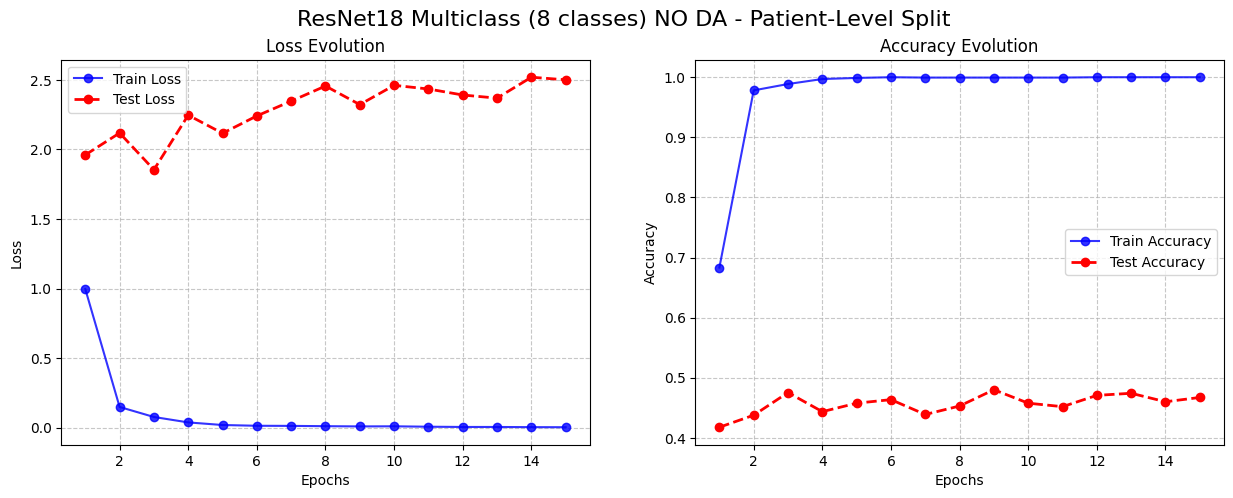

In [10]:
import matplotlib.pyplot as plt

# Data extracted from training (Multiclass NO Data Augmentation)
epochs = range(1, 16)
train_loss = [0.9963, 0.1483, 0.0762, 0.0372, 0.0185, 0.0130, 0.0122, 0.0101, 0.0084, 0.0092, 0.0062, 0.0045, 0.0044, 0.0031, 0.0026]
test_loss = [1.9610, 2.1186, 1.8543, 2.2469, 2.1165, 2.2415, 2.3479, 2.4565, 2.3228, 2.4614, 2.4350, 2.3918, 2.3693, 2.5197, 2.5011]
train_acc = [0.6833, 0.9781, 0.9887, 0.9970, 0.9988, 1.0000, 0.9994, 0.9994, 0.9994, 0.9994, 0.9994, 1.0000, 1.0000, 1.0000, 1.0000]
test_acc = [0.4176, 0.4376, 0.4753, 0.4435, 0.4576, 0.4635, 0.4388, 0.4529, 0.4800, 0.4576, 0.4518, 0.4706, 0.4741, 0.4600, 0.4671]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet18 Multiclass (8 classes) NO DA - Patient-Level Split', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Confusion matriz of the CNN ResNet 18 without data augmentation


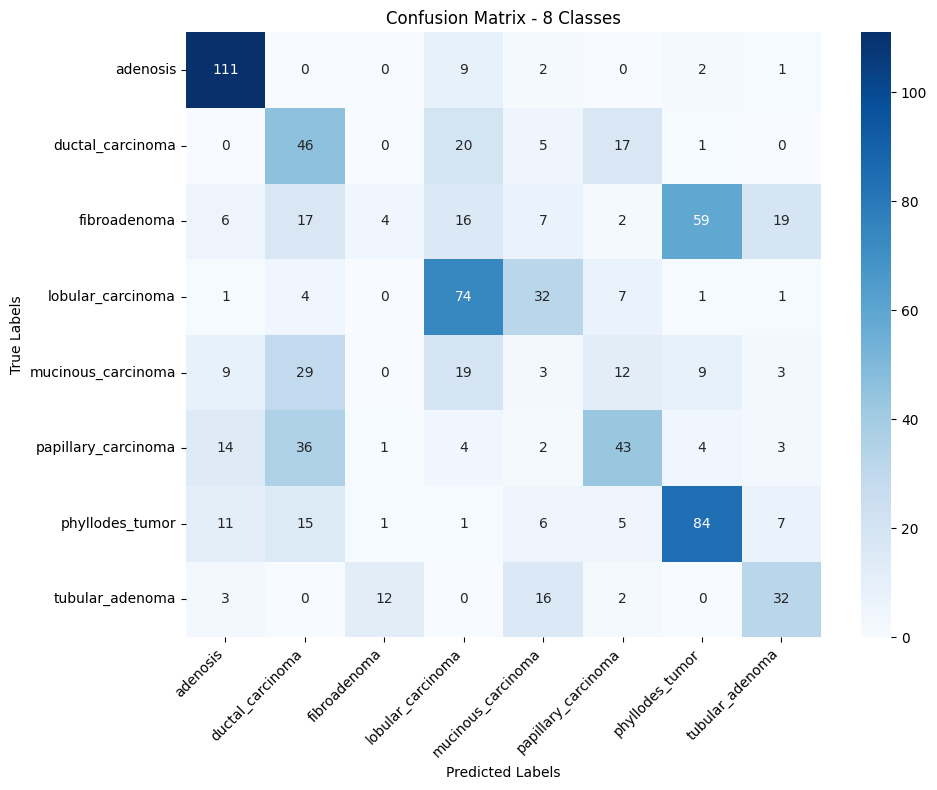

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - 8 Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

After the training is done, the performances per class with this CNN ResNet18 without data augmentation are:


In [7]:
from sklearn.metrics import classification_report

# Using the all_preds and all_labels from the previous evaluation block
print("Detailed Performance per Class:")
print("-" * 50)

# target_names maps the numeric labels (0 to 7) back to the folder names
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

Detailed Performance per Class:
--------------------------------------------------
                     precision    recall  f1-score   support

           adenosis       0.72      0.89      0.79       125
   ductal_carcinoma       0.31      0.52      0.39        89
       fibroadenoma       0.22      0.03      0.05       130
  lobular_carcinoma       0.52      0.62      0.56       120
 mucinous_carcinoma       0.04      0.04      0.04        84
papillary_carcinoma       0.49      0.40      0.44       107
    phyllodes_tumor       0.53      0.65      0.58       130
    tubular_adenoma       0.48      0.49      0.49        65

           accuracy                           0.47       850
          macro avg       0.41      0.45      0.42       850
       weighted avg       0.43      0.47      0.43       850



Let's move on to the CNN with data augmentation:

In [8]:
import torch
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import time

# 1. Dataloaders with Data Augmentation
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test ALWAYS goes without augmentations
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

train_loader_da = DataLoader(train_dataset_da, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

# 2. Initialise the CNN model with data augmentation for MULTICLASS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn_da = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_cnn_da.parameters():
    param.requires_grad = True

num_ftrs = model_cnn_da.fc.in_features
num_classes = len(train_dataset_da.classes) # Automatically detects 8 classes

# Modify for 8 classes
model_cnn_da.fc = nn.Linear(num_ftrs, num_classes)
model_cnn_da = model_cnn_da.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn_da.parameters(), lr=0.0001)

print(f"ResNet18 (with DA) architecture ready for {num_classes}-class classification.")

ResNet18 (with DA) architecture ready for 8-class classification.


In [9]:
import time

NUM_EPOCHS = 15
print("Starting training for the clean experiment (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model with a name indicating it is the clean split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_DA_patient_split.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_DA_patient_split.pth'")

Starting training for the clean experiment (Patient-Level Split)...

Epoch 1/15 (13.7s) -> Train Loss: 0.0027 | Train Acc: 1.0000 || Test Loss: 2.4960 | Test Acc: 0.4647
Epoch 2/15 (13.0s) -> Train Loss: 0.0027 | Train Acc: 1.0000 || Test Loss: 2.4977 | Test Acc: 0.4541
Epoch 3/15 (13.3s) -> Train Loss: 0.0039 | Train Acc: 1.0000 || Test Loss: 2.4974 | Test Acc: 0.4659
Epoch 4/15 (13.3s) -> Train Loss: 0.0029 | Train Acc: 1.0000 || Test Loss: 2.4461 | Test Acc: 0.4824
Epoch 5/15 (13.2s) -> Train Loss: 0.0030 | Train Acc: 1.0000 || Test Loss: 2.4537 | Test Acc: 0.4776
Epoch 6/15 (13.6s) -> Train Loss: 0.0040 | Train Acc: 0.9994 || Test Loss: 2.5335 | Test Acc: 0.4647
Epoch 7/15 (13.7s) -> Train Loss: 0.0023 | Train Acc: 1.0000 || Test Loss: 2.4564 | Test Acc: 0.4729
Epoch 8/15 (13.6s) -> Train Loss: 0.0029 | Train Acc: 1.0000 || Test Loss: 2.5560 | Test Acc: 0.4600
Epoch 9/15 (13.3s) -> Train Loss: 0.0026 | Train Acc: 1.0000 || Test Loss: 2.4945 | Test Acc: 0.4729
Epoch 10/15 (16.4s) ->

Graphical representation of the data:

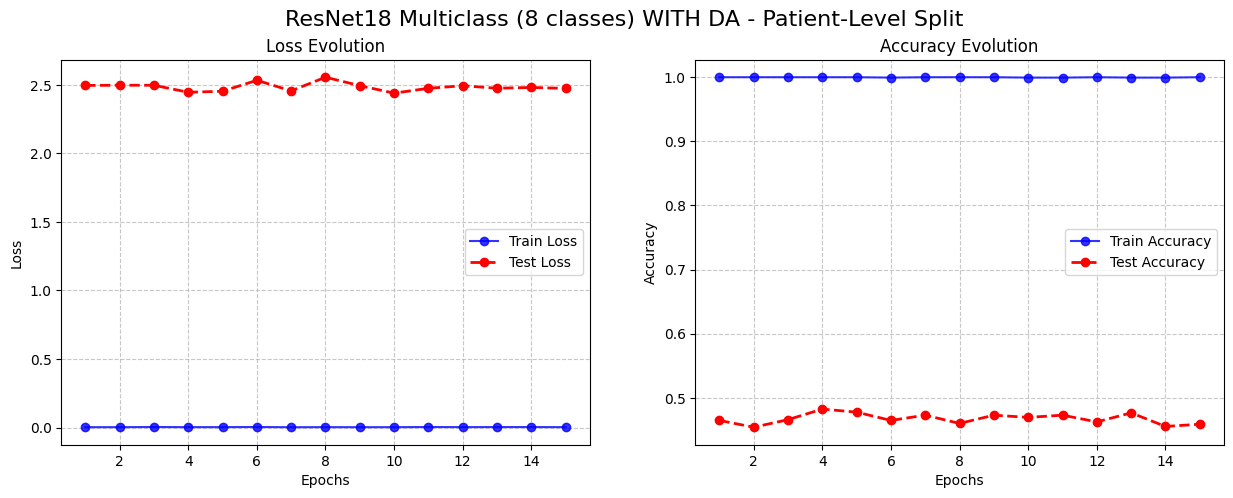

In [23]:
import matplotlib.pyplot as plt

# Data extracted from CNN training (Multiclass WITH Data Augmentation)
epochs = range(1, 16)
train_loss = [0.0027, 0.0027, 0.0039, 0.0029, 0.0030, 0.0040, 0.0023, 0.0029, 0.0026, 0.0027, 0.0038, 0.0030, 0.0035, 0.0035, 0.0028]
test_loss = [2.4960, 2.4977, 2.4974, 2.4461, 2.4537, 2.5335, 2.4564, 2.5560, 2.4945, 2.4399, 2.4752, 2.4938, 2.4755, 2.4813, 2.4743]
train_acc = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9994, 1.0000, 1.0000, 1.0000, 0.9994, 0.9994, 1.0000, 0.9994, 0.9994, 1.0000]
test_acc = [0.4647, 0.4541, 0.4659, 0.4824, 0.4776, 0.4647, 0.4729, 0.4600, 0.4729, 0.4694, 0.4729, 0.4624, 0.4765, 0.4553, 0.4588]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet18 Multiclass (8 classes) WITH DA - Patient-Level Split', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Confusion marix of the model:

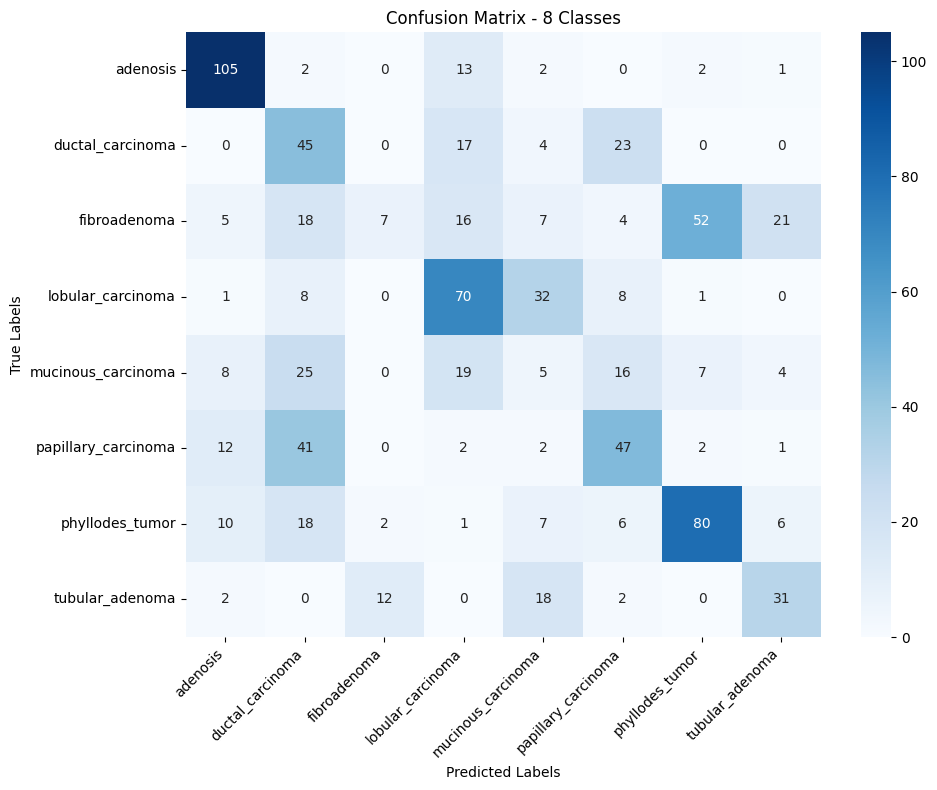

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - 8 Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report

# Using the all_preds and all_labels from the previous evaluation block
print("Detailed Performance per Class:")
print("-" * 50)

# target_names maps the numeric labels (0 to 7) back to the folder names
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

Detailed Performance per Class:
--------------------------------------------------
                     precision    recall  f1-score   support

           adenosis       0.73      0.84      0.78       125
   ductal_carcinoma       0.29      0.51      0.37        89
       fibroadenoma       0.33      0.05      0.09       130
  lobular_carcinoma       0.51      0.58      0.54       120
 mucinous_carcinoma       0.06      0.06      0.06        84
papillary_carcinoma       0.44      0.44      0.44       107
    phyllodes_tumor       0.56      0.62      0.58       130
    tubular_adenoma       0.48      0.48      0.48        65

           accuracy                           0.46       850
          macro avg       0.43      0.45      0.42       850
       weighted avg       0.44      0.46      0.43       850



Let's move on to the ViT models, where I will train first the one without data augmentation

Dataloaders and initialise the model

In [13]:
from torchvision import models

# Load a pre-trained ViT model
# vit_b_16 is a standard base model with 16x16 patches
weights = models.ViT_B_16_Weights.IMAGENET1K_V1
model_vit = models.vit_b_16(weights=weights)

# Unfreeze all parameters
for param in model_vit.parameters():
    param.requires_grad = True

# Modify the classification head for 8 classes
# In ViT, the head is called 'heads' (an nn.Sequential layer)
num_ftrs = model_vit.heads.head.in_features
model_vit.heads.head = nn.Linear(num_ftrs, num_classes) # num_classes = 8

model_vit = model_vit.to(device)

# Optimizer and Criterion remain the same
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit.parameters(), lr=0.0001)

print("ViT_B_16 architecture ready for 8-class classification.")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 53.0MB/s]


ViT_B_16 architecture ready for 8-class classification.


Train and save the model

In [14]:
import time

# Define the number of epochs
NUM_EPOCHS = 15

print("Starting training with ViT_B_16 (Multiclass)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING PHASE
    model_vit.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader: # Asegúrate de usar el loader correcto
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_vit(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION (TEST) PHASE
    model_vit.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_vit(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_b_16_patient_split.pth"
torch.save(model_vit.state_dict(), save_path)
print(f"Model saved as 'vit_b_16_patient_split.pth'")

Starting training with ViT_B_16 (Multiclass)...

Epoch 1/15 (74.6s) -> Train Loss: 1.2417 | Train Acc: 0.5664 || Test Loss: 2.2752 | Test Acc: 0.3553
Epoch 2/15 (81.8s) -> Train Loss: 0.2985 | Train Acc: 0.9146 || Test Loss: 2.1945 | Test Acc: 0.4494
Epoch 3/15 (82.9s) -> Train Loss: 0.0903 | Train Acc: 0.9751 || Test Loss: 2.3496 | Test Acc: 0.3976
Epoch 4/15 (81.8s) -> Train Loss: 0.0757 | Train Acc: 0.9763 || Test Loss: 2.6339 | Test Acc: 0.4541
Epoch 5/15 (83.5s) -> Train Loss: 0.0283 | Train Acc: 0.9923 || Test Loss: 3.0536 | Test Acc: 0.3859
Epoch 6/15 (84.0s) -> Train Loss: 0.0252 | Train Acc: 0.9953 || Test Loss: 2.7664 | Test Acc: 0.4671
Epoch 7/15 (86.7s) -> Train Loss: 0.0032 | Train Acc: 1.0000 || Test Loss: 2.8972 | Test Acc: 0.4753
Epoch 8/15 (84.5s) -> Train Loss: 0.0012 | Train Acc: 1.0000 || Test Loss: 2.9816 | Test Acc: 0.4706
Epoch 9/15 (81.8s) -> Train Loss: 0.0010 | Train Acc: 1.0000 || Test Loss: 3.0352 | Test Acc: 0.4706
Epoch 10/15 (81.8s) -> Train Loss: 0.0009 

Graphical representation of the data

In [ ]:
import matplotlib.pyplot as plt

# Data extracted from ViT training (Multiclass NO Data Augmentation)
epochs = range(1, 16)
train_loss = [1.2417, 0.2985, 0.0903, 0.0757, 0.0283, 0.0252, 0.0032, 0.0012, 0.0010, 0.0009, 0.0008, 0.0007, 0.0006, 0.0005, 0.0005]
test_loss = [2.2752, 2.1945, 2.3496, 2.6339, 3.0536, 2.7664, 2.8972, 2.9816, 3.0352, 3.0796, 3.1207, 3.1582, 3.1918, 3.2182, 3.2455]
train_acc = [0.5664, 0.9146, 0.9751, 0.9763, 0.9923, 0.9953, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
test_acc = [0.3553, 0.4494, 0.3976, 0.4541, 0.3859, 0.4671, 0.4753, 0.4706, 0.4706, 0.4694, 0.4706, 0.4659, 0.4647, 0.4671, 0.4635]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ViT_B_16 Multiclass (8 classes) NO DA - Patient-Level Split', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Confusion matrix

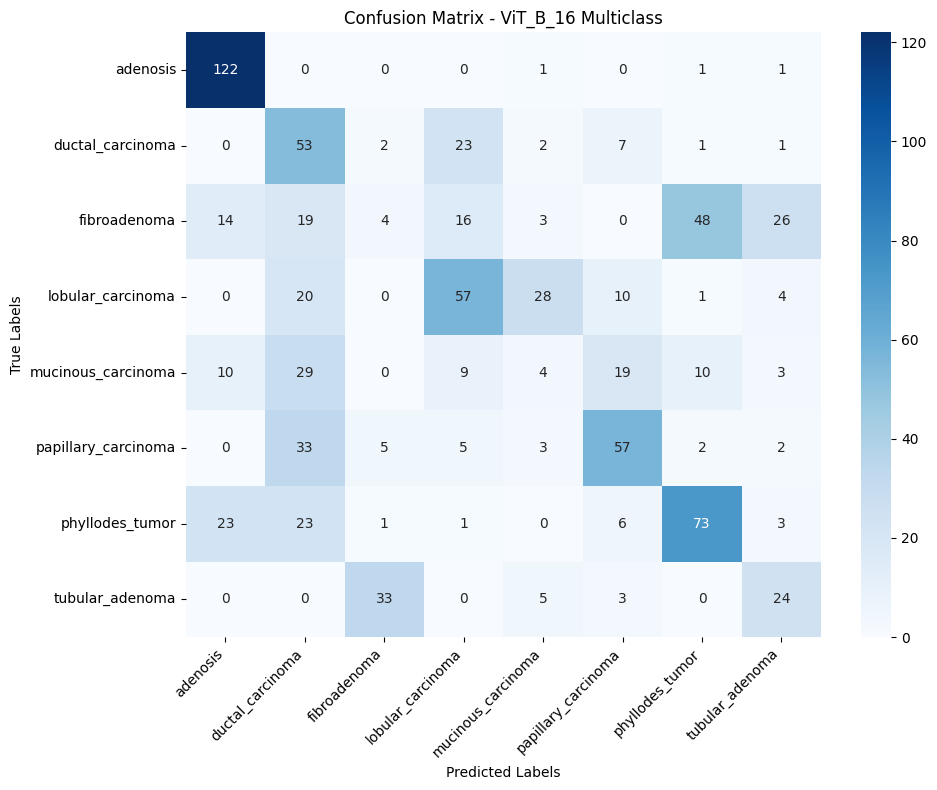

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model_vit.eval()
all_preds = []
all_labels = []

# Collect predictions
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_vit(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.classes # Automatically gets the 8 class names from the folder structure

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT_B_16 Multiclass')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Classification Report (metrics)

In [16]:
from sklearn.metrics import classification_report

# Output detailed metrics per class
print("Detailed Performance Report per Class (ViT_B_16):")
print("-" * 50)

# Calculate and print the report
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

Detailed Performance Report per Class (ViT_B_16):
--------------------------------------------------
                     precision    recall  f1-score   support

           adenosis       0.72      0.98      0.83       125
   ductal_carcinoma       0.30      0.60      0.40        89
       fibroadenoma       0.09      0.03      0.05       130
  lobular_carcinoma       0.51      0.47      0.49       120
 mucinous_carcinoma       0.09      0.05      0.06        84
papillary_carcinoma       0.56      0.53      0.55       107
    phyllodes_tumor       0.54      0.56      0.55       130
    tubular_adenoma       0.38      0.37      0.37        65

           accuracy                           0.46       850
          macro avg       0.40      0.45      0.41       850
       weighted avg       0.41      0.46      0.43       850



Let's now study the behaviour of a ViT model with data augmentation

In [17]:
# 1. Define DataLoaders with Data Augmentation
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test transformation remains standard
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

# DataLoaders
train_loader_da = DataLoader(train_dataset_da, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

# 2. Initialise the ViT model
model_vit_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Unfreeze parameters
for param in model_vit_da.parameters():
    param.requires_grad = True

# Modify the classification head for 8 classes
num_ftrs = model_vit_da.heads.head.in_features
model_vit_da.heads.head = nn.Linear(num_ftrs, 8)
model_vit_da = model_vit_da.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit_da.parameters(), lr=0.0001)

print("ViT_B_16 (with DA) architecture ready.")

ViT_B_16 (with DA) architecture ready.


Train and save

In [18]:
import time

# Define the number of epochs
NUM_EPOCHS = 15

print("Starting training with ViT_B_16 (Multiclass)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING PHASE
    model_vit.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader: # Asegúrate de usar el loader correcto
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_vit(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION (TEST) PHASE
    model_vit.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_vit(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_b_16_DA_patient_split.pth"
torch.save(model_vit.state_dict(), save_path)
print(f"Model saved as 'vit_b_16_DA_patient_split.pth'")

Starting training with ViT_B_16 (Multiclass)...

Epoch 1/15 (80.0s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 2/15 (80.9s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 3/15 (80.7s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 4/15 (80.6s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 5/15 (80.6s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 6/15 (80.4s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 7/15 (80.7s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 8/15 (80.7s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 9/15 (80.4s) -> Train Loss: 0.0005 | Train Acc: 1.0000 || Test Loss: 3.2455 | Test Acc: 0.4635
Epoch 10/15 (80.6s) -> Train Loss: 0.0005 

Graphical representation of the data

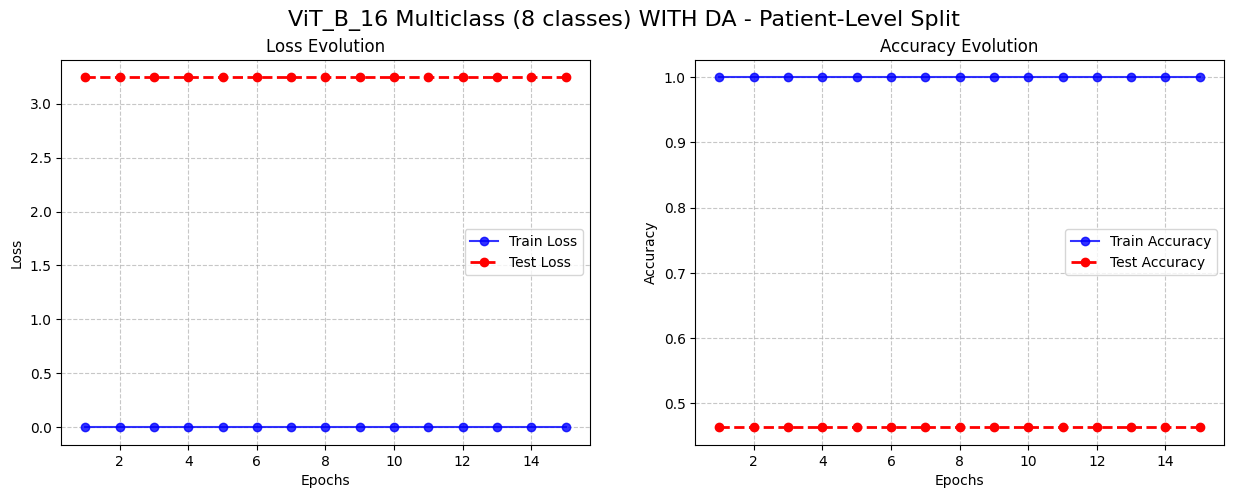

In [19]:
import matplotlib.pyplot as plt

# Data extracted from ViT training (Multiclass WITH Data Augmentation)
epochs = range(1, 16)
# All values remained constant after epoch 1
train_loss = [0.0005] * 15
test_loss = [3.2455] * 15
train_acc = [1.0000] * 15
test_acc = [0.4635] * 15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ViT_B_16 Multiclass (8 classes) WITH DA - Patient-Level Split', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Confusion matrix

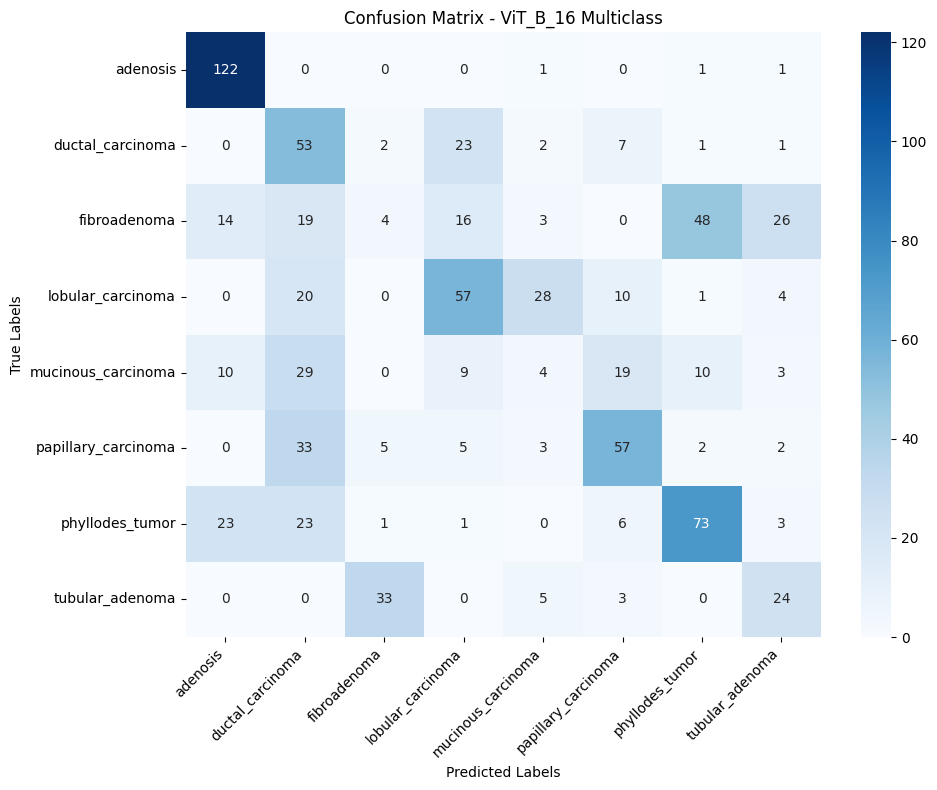

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model_vit.eval()
all_preds = []
all_labels = []

# Collect predictions
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_vit(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.classes # Automatically gets the 8 class names from the folder structure

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT_B_16 Multiclass')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Metrics of the model

In [22]:
from sklearn.metrics import classification_report

# Output detailed metrics per class
print("Detailed Performance Report per Class (ViT_B_16):")
print("-" * 50)

# Calculate and print the report
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

Detailed Performance Report per Class (ViT_B_16):
--------------------------------------------------
                     precision    recall  f1-score   support

           adenosis       0.72      0.98      0.83       125
   ductal_carcinoma       0.30      0.60      0.40        89
       fibroadenoma       0.09      0.03      0.05       130
  lobular_carcinoma       0.51      0.47      0.49       120
 mucinous_carcinoma       0.09      0.05      0.06        84
papillary_carcinoma       0.56      0.53      0.55       107
    phyllodes_tumor       0.54      0.56      0.55       130
    tubular_adenoma       0.38      0.37      0.37        65

           accuracy                           0.46       850
          macro avg       0.40      0.45      0.41       850
       weighted avg       0.41      0.46      0.43       850



As every experiment was a failure, the next step here is to change some of the models characteristics in order to achieve better performances. I will start with the CNN adding dropout:

In [24]:
# Load the pre-trained ResNet18
model_cnn_dropout = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final layers
num_ftrs = model_cnn_dropout.fc.in_features

# We replace the final layer with a sequence that includes Dropout
# This will help prevent the model from memorizing the training data
model_cnn_dropout.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 8)
)

model_cnn_dropout = model_cnn_dropout.to(device)

# Re-initialize optimizer
optimizer = optim.Adam(model_cnn_dropout.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

print("ResNet18 with Dropout (p=0.5) initialized.")

ResNet18 with Dropout (p=0.5) initialized.


In [25]:
import time

NUM_EPOCHS = 15
print("Starting training for the experiment with Dropout (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn_dropout.train()  # Using the dropout model
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da: # Ensure using the loader with DA if desired
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn_dropout(inputs) # Corrected variable name
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn_dropout.eval() # Corrected variable name
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn_dropout(inputs) # Corrected variable name
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model with a name indicating it includes dropout
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_resnet18_dropout_da.pth"
torch.save(model_cnn_dropout.state_dict(), save_path)
print(f"Model saved as 'cnn_resnet18_dropout_da.pth'")

Starting training for the experiment with Dropout (Patient-Level Split)...

Epoch 1/15 (16.4s) -> Train Loss: 1.5015 | Train Acc: 0.4632 || Test Loss: 2.0079 | Test Acc: 0.4024
Epoch 2/15 (16.5s) -> Train Loss: 0.6062 | Train Acc: 0.8013 || Test Loss: 1.9306 | Test Acc: 0.4682
Epoch 3/15 (17.1s) -> Train Loss: 0.3785 | Train Acc: 0.8796 || Test Loss: 2.1228 | Test Acc: 0.4624
Epoch 4/15 (16.9s) -> Train Loss: 0.2770 | Train Acc: 0.9122 || Test Loss: 2.4660 | Test Acc: 0.4424
Epoch 5/15 (16.5s) -> Train Loss: 0.1796 | Train Acc: 0.9484 || Test Loss: 2.2901 | Test Acc: 0.4494
Epoch 6/15 (16.6s) -> Train Loss: 0.1541 | Train Acc: 0.9526 || Test Loss: 2.8205 | Test Acc: 0.3859
Epoch 7/15 (16.6s) -> Train Loss: 0.1489 | Train Acc: 0.9520 || Test Loss: 2.7308 | Test Acc: 0.4447
Epoch 8/15 (16.5s) -> Train Loss: 0.1027 | Train Acc: 0.9692 || Test Loss: 2.4096 | Test Acc: 0.4682
Epoch 9/15 (16.6s) -> Train Loss: 0.0784 | Train Acc: 0.9733 || Test Loss: 2.5520 | Test Acc: 0.4318
Epoch 10/15 (17

Graphical representation of the results

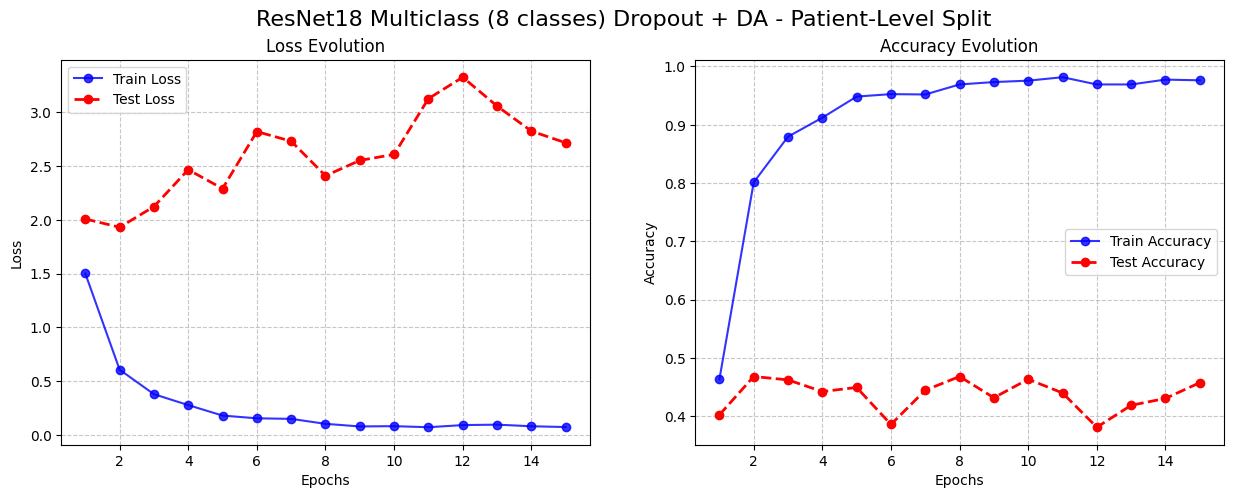

In [26]:
import matplotlib.pyplot as plt

# Data extracted from CNN training (Multiclass WITH Dropout + DA)
epochs = range(1, 16)
train_loss = [1.5015, 0.6062, 0.3785, 0.2770, 0.1796, 0.1541, 0.1489, 0.1027, 0.0784, 0.0810, 0.0712, 0.0909, 0.0952, 0.0801, 0.0728]
test_loss = [2.0079, 1.9306, 2.1228, 2.4660, 2.2901, 2.8205, 2.7308, 2.4096, 2.5520, 2.6082, 3.1267, 3.3259, 3.0577, 2.8248, 2.7161]
train_acc = [0.4632, 0.8013, 0.8796, 0.9122, 0.9484, 0.9526, 0.9520, 0.9692, 0.9733, 0.9757, 0.9816, 0.9692, 0.9692, 0.9775, 0.9763]
test_acc = [0.4024, 0.4682, 0.4624, 0.4424, 0.4494, 0.3859, 0.4447, 0.4682, 0.4318, 0.4635, 0.4400, 0.3812, 0.4188, 0.4306, 0.4576]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet18 Multiclass (8 classes) Dropout + DA - Patient-Level Split', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

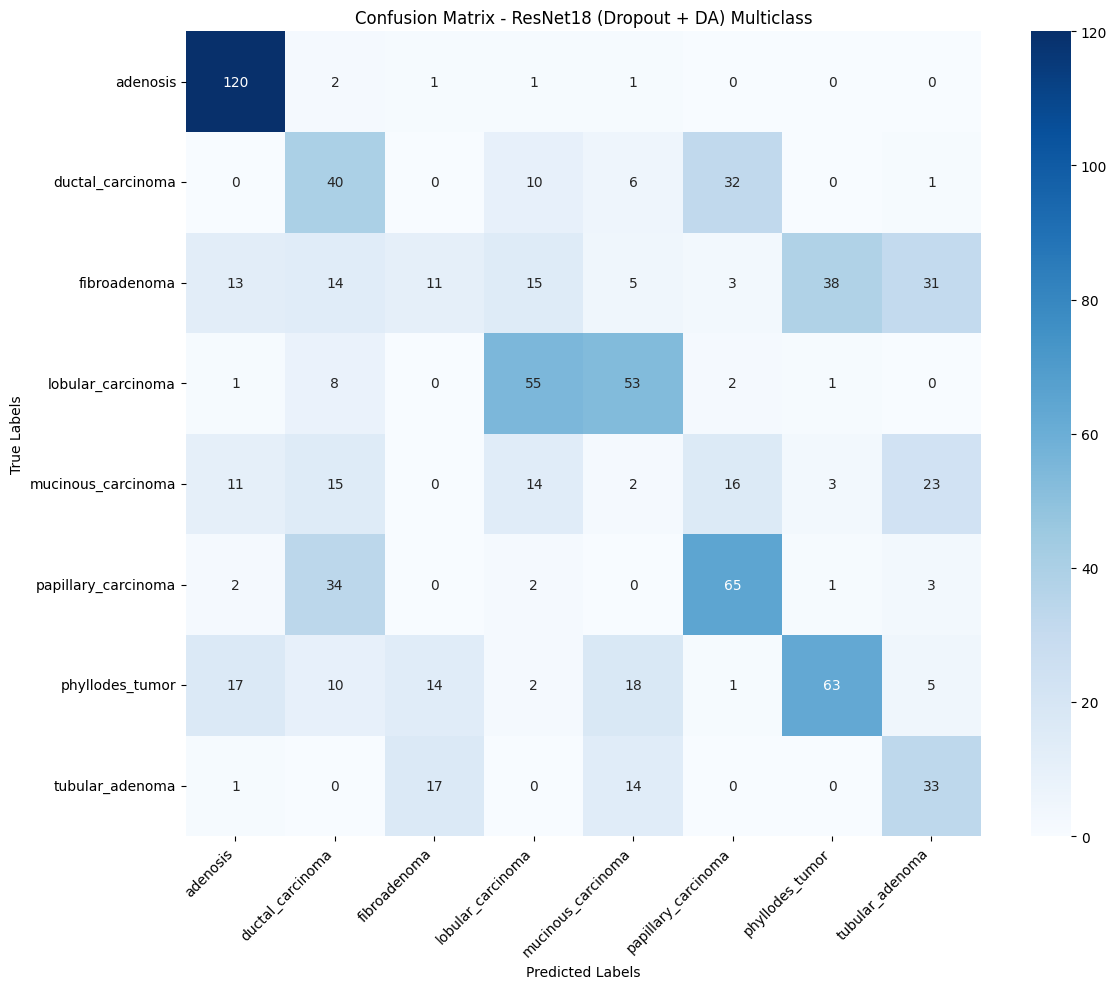

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# Ensure the model is in evaluation mode
model_cnn_dropout.eval()
all_preds = []
all_labels = []

# Collect predictions on the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_cnn_dropout(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.classes

# Plotting the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ResNet18 (Dropout + DA) Multiclass')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Advanced configuration for the CNN model

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Calcular pesos para balancear las clases
# Accedemos a los targets del dataset de entrenamiento
targets = train_dataset_da.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# 2. Configurar el Criterio con Label Smoothing y Pesos
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# 3. Inicializar el optimizador y el Scheduler
optimizer = optim.Adam(model_cnn_dropout.parameters(), lr=0.0001)

# Corregido: eliminado el argumento 'verbose'
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("Advanced Training Configuration (Weighted Loss, Label Smoothing, Scheduler) ready.")

Advanced Training Configuration (Weighted Loss, Label Smoothing, Scheduler) ready.


Training and save

In [31]:
import time

NUM_EPOCHS = 20 # He subido a 20 épocas porque el scheduler necesita tiempo para actuar
print("Starting Advanced Training (Weighted Loss + Label Smoothing + Scheduler)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn_dropout.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn_dropout(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn_dropout.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn_dropout(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    # Step the scheduler based on validation loss
    scheduler.step(epoch_test_loss)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f} | "
          f"LR: {current_lr:.6f}")

print("\nTraining finished successfully.")

# Save the advanced model
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_advanced_final.pth"
torch.save(model_cnn_dropout.state_dict(), save_path)
print(f"Model saved as 'cnn_advanced_final.pth'")

Starting Advanced Training (Weighted Loss + Label Smoothing + Scheduler)...

Epoch 1/20 (16.8s) -> Train Loss: 0.7779 | Train Acc: 0.9650 || Test Loss: 2.1832 | Test Acc: 0.4212 | LR: 0.000100
Epoch 2/20 (16.6s) -> Train Loss: 0.6510 | Train Acc: 0.9745 || Test Loss: 1.9754 | Test Acc: 0.4247 | LR: 0.000100
Epoch 3/20 (16.7s) -> Train Loss: 0.6257 | Train Acc: 0.9822 || Test Loss: 2.0498 | Test Acc: 0.4000 | LR: 0.000100
Epoch 4/20 (17.0s) -> Train Loss: 0.6220 | Train Acc: 0.9781 || Test Loss: 2.0179 | Test Acc: 0.4141 | LR: 0.000100
Epoch 5/20 (17.3s) -> Train Loss: 0.6108 | Train Acc: 0.9846 || Test Loss: 1.9999 | Test Acc: 0.4494 | LR: 0.000050
Epoch 6/20 (16.7s) -> Train Loss: 0.5963 | Train Acc: 0.9887 || Test Loss: 1.9400 | Test Acc: 0.4447 | LR: 0.000050
Epoch 7/20 (16.8s) -> Train Loss: 0.5870 | Train Acc: 0.9881 || Test Loss: 1.9170 | Test Acc: 0.4447 | LR: 0.000050
Epoch 8/20 (16.5s) -> Train Loss: 0.5860 | Train Acc: 0.9905 || Test Loss: 1.9013 | Test Acc: 0.4494 | LR: 0.00

So in this previous experiment where ResNet18 was still implemented, there was little to no improvement. Now, there is a need to be ''agressive'' with this new training. The next step here is to try another CNN model with more specific improvements in order to adapt it and successfully train it to the new multiclass environment

In [5]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Detectar automáticamente el mejor hardware disponible (CUDA para Google Colab, MPS para Mac, o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# TEST DATA LOADER (No augmentation, only normalization)
# ==========================================
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print("Test loader ready.")

# ==========================================
# 1. ADVANCED DATA AUGMENTATION (STAIN INVARIANCE)
# ==========================================
transform_train_extreme = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    # ColorJitter is crucial for medical H&E stained images
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reload the training dataset with the new extreme transforms
train_dataset_extreme = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_extreme)
train_loader_extreme = DataLoader(train_dataset_extreme, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)

# ==========================================
# 2. ARCHITECTURE SWAP: DENSENET121
# ==========================================
print("Initializing DenseNet121...")
model_dense = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Replace the classifier head for 8 classes + high dropout
num_ftrs = model_dense.classifier.in_features
model_dense.classifier = nn.Sequential(
    nn.Dropout(p=0.6), # Increased dropout to 60%
    nn.Linear(num_ftrs, 8)
)
model_dense = model_dense.to(device)

# ==========================================
# 3. DIFFERENTIAL LEARNING RATES & WEIGHT DECAY
# ==========================================
# Separate parameters into backbone (pretrained) and classifier (new)
backbone_params = [param for name, param in model_dense.named_parameters() if 'classifier' not in name]
classifier_params = model_dense.classifier.parameters()

# Backbone learns 100x slower than the classifier. Added Weight Decay (L2).
optimizer_dense = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': classifier_params, 'lr': 1e-3}
], weight_decay=1e-4)

# ==========================================
# 4. LOSS FUNCTION & SCHEDULER
# ==========================================
targets = train_dataset_extreme.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Label smoothing prevents overconfidence
criterion_dense = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_dense = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dense, mode='min', patience=3, factor=0.5)

# ==========================================
# 5. TRAINING LOOP WITH GRADIENT CLIPPING
# ==========================================
NUM_EPOCHS = 20
print("Starting Ultimate Training Pipeline (DenseNet121 + ColorJitter + Diff LR)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- TRAIN ---
    model_dense.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_extreme:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer_dense.zero_grad()
        outputs = model_dense(inputs)
        loss = criterion_dense(outputs, labels)

        loss.backward()
        # Gradient Clipping: Prevents exploding gradients in complex architectures
        torch.nn.utils.clip_grad_norm_(model_dense.parameters(), max_norm=2.0)
        optimizer_dense.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION ---
    model_dense.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader: # Uses your existing test_loader
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model_dense(inputs)
            loss = criterion_dense(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    # Step the scheduler based on validation loss
    scheduler_dense.step(epoch_test_loss)
    current_lr_backbone = optimizer_dense.param_groups[0]['lr']

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f} | "
          f"Backbone LR: {current_lr_backbone:.6f}")

print("\nTraining finished successfully.")
torch.save(model_dense.state_dict(), "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/densenet121_ultimate.pth")
print("Model saved as 'densenet121_ultimate.pth'")

Using device: cuda
Test loader ready.
Initializing DenseNet121...
Starting Ultimate Training Pipeline (DenseNet121 + ColorJitter + Diff LR)...

Epoch 1/20 (43.8s) -> Train Loss: 2.1156 | Train Acc: 0.2147 || Test Loss: 1.9467 | Test Acc: 0.2682 | Backbone LR: 0.000010
Epoch 2/20 (44.3s) -> Train Loss: 1.8748 | Train Acc: 0.3351 || Test Loss: 1.9031 | Test Acc: 0.3341 | Backbone LR: 0.000010
Epoch 3/20 (44.4s) -> Train Loss: 1.6908 | Train Acc: 0.4253 || Test Loss: 1.8506 | Test Acc: 0.3506 | Backbone LR: 0.000010
Epoch 4/20 (42.7s) -> Train Loss: 1.6154 | Train Acc: 0.4727 || Test Loss: 1.8247 | Test Acc: 0.3682 | Backbone LR: 0.000010
Epoch 5/20 (43.0s) -> Train Loss: 1.5595 | Train Acc: 0.5113 || Test Loss: 1.8283 | Test Acc: 0.3941 | Backbone LR: 0.000010
Epoch 6/20 (42.5s) -> Train Loss: 1.4467 | Train Acc: 0.5522 || Test Loss: 1.8749 | Test Acc: 0.4141 | Backbone LR: 0.000010
Epoch 7/20 (41.3s) -> Train Loss: 1.4287 | Train Acc: 0.5771 || Test Loss: 1.8866 | Test Acc: 0.4071 | Bac

Graphical representation of the data

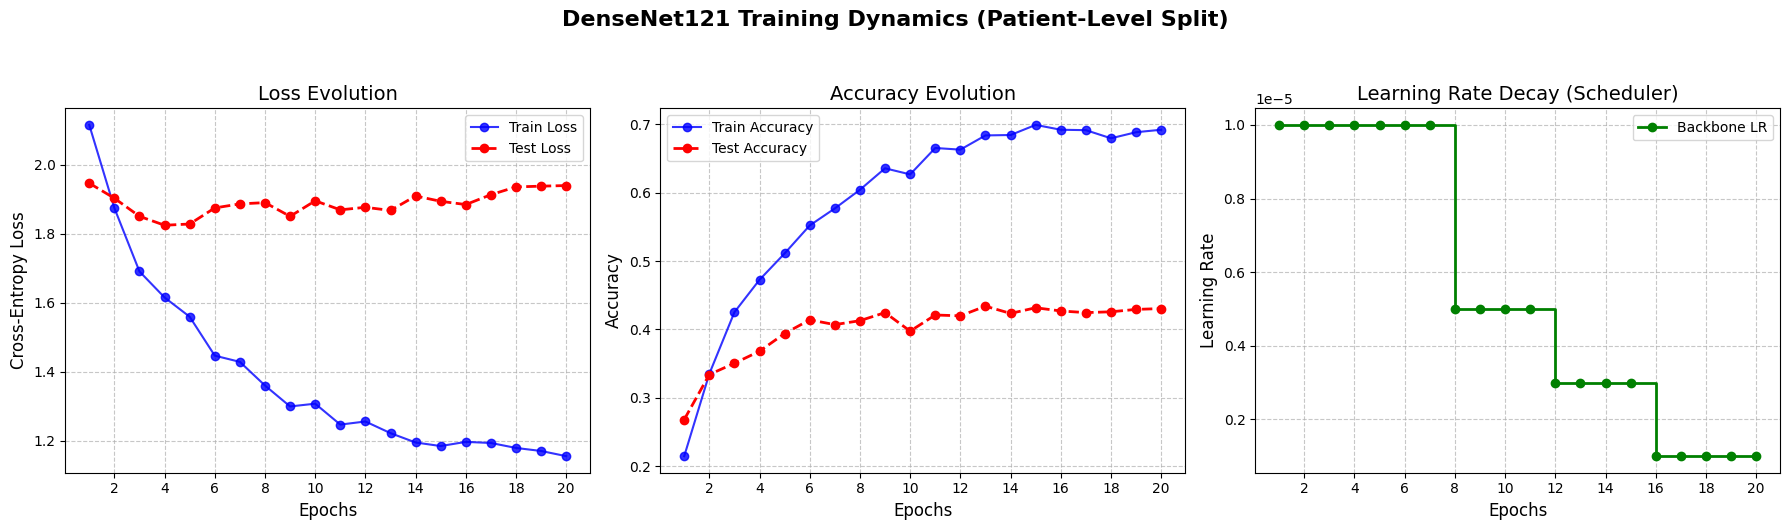

In [9]:
import matplotlib.pyplot as plt

# ==========================================
# DATA EXTRACTION (DenseNet121 Ultimate)
# ==========================================
epochs = range(1, 21)

train_loss = [2.1156, 1.8748, 1.6908, 1.6154, 1.5595, 1.4467, 1.4287, 1.3602, 1.2995, 1.3075, 1.2469, 1.2559, 1.2221, 1.1950, 1.1847, 1.1968, 1.1936, 1.1792, 1.1704, 1.1554]
test_loss = [1.9467, 1.9031, 1.8506, 1.8247, 1.8283, 1.8749, 1.8866, 1.8903, 1.8505, 1.8956, 1.8694, 1.8767, 1.8677, 1.9095, 1.8941, 1.8847, 1.9133, 1.9359, 1.9380, 1.9398]

train_acc = [0.2147, 0.3351, 0.4253, 0.4727, 0.5113, 0.5522, 0.5771, 0.6044, 0.6358, 0.6269, 0.6655, 0.6631, 0.6839, 0.6845, 0.6993, 0.6922, 0.6916, 0.6797, 0.6886, 0.6922]
test_acc = [0.2682, 0.3341, 0.3506, 0.3682, 0.3941, 0.4141, 0.4071, 0.4129, 0.4247, 0.3976, 0.4212, 0.4200, 0.4341, 0.4235, 0.4318, 0.4271, 0.4247, 0.4259, 0.4294, 0.4306]

# Note: Using scientific notation for LR to make the Y-axis cleaner
lr_backbone = [1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 5e-6, 5e-6, 5e-6, 5e-6, 3e-6, 3e-6, 3e-6, 3e-6, 1e-6, 1e-6, 1e-6, 1e-6, 1e-6]

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DenseNet121 Training Dynamics (Patient-Level Split)', fontsize=16, fontweight='bold', y=1.05)

# 1. Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(range(2, 21, 2))

# 2. Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xticks(range(2, 21, 2))

# 3. Learning Rate Plot
ax3.step(epochs, lr_backbone, 'g-o', label='Backbone LR', linewidth=2, where='post')
ax3.set_title('Learning Rate Decay (Scheduler)', fontsize=14)
ax3.set_xlabel('Epochs', fontsize=12)
ax3.set_ylabel('Learning Rate', fontsize=12)
ax3.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_xticks(range(2, 21, 2))

plt.tight_layout()

# Save for the thesis
plt.savefig('/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/training_curves_densenet.png', dpi=300, bbox_inches='tight')
plt.show()

A sample of the extreme data augmentation can be seen here:

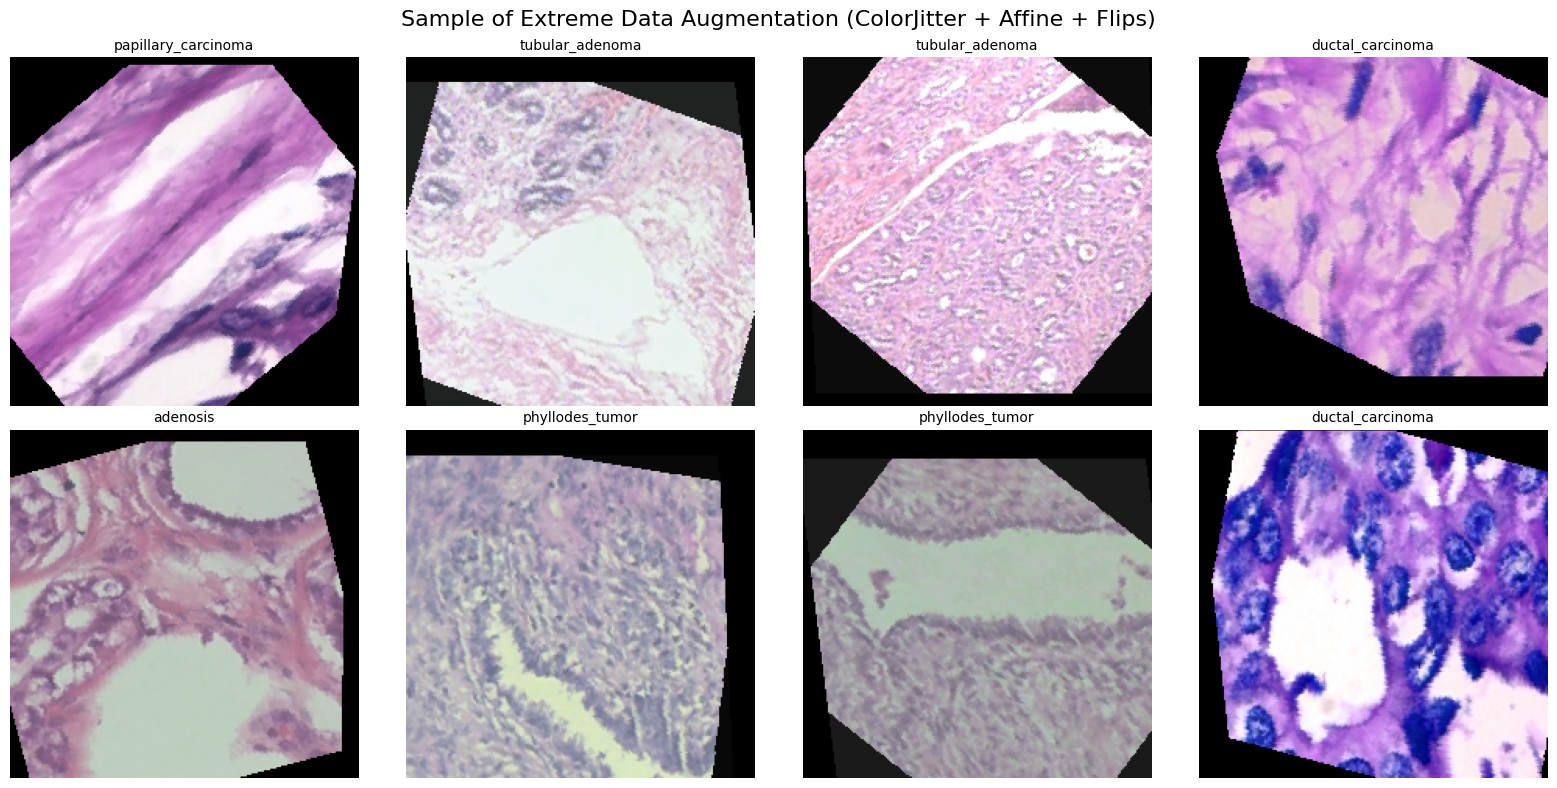

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# ==========================================
# VISUALIZE EXTREME DATA AUGMENTATION
# ==========================================

def imshow_denormalized(tensor_img, title=None):
    """
    Imshow for Tensors. De-normalizes the image so it can be
    displayed correctly by matplotlib.
    """
    # Convert tensor to numpy array
    img = tensor_img.numpy().transpose((1, 2, 0))

    # ImageNet normalization parameters used in transforms
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # De-normalize: img = img * std + mean
    img = std * img + mean
    # Clip values to be between 0 and 1 for matplotlib
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')

# Get a batch of training data from the extreme loader
# Make sure train_loader_extreme is already defined and loaded
dataiter = iter(train_loader_extreme)
images, labels = next(dataiter)

# Select the first 8 images from the batch for visualization
num_images_to_show = 8
images_to_show = images[:num_images_to_show]
labels_to_show = labels[:num_images_to_show]

# Get the class names from the dataset
class_names = train_dataset_extreme.classes

# Plot the images in a grid
fig = plt.figure(figsize=(16, 8))
fig.suptitle("Sample of Extreme Data Augmentation (ColorJitter + Affine + Flips)", fontsize=16)

for idx in range(num_images_to_show):
    ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])
    # Pass the individual image tensor to our helper function
    imshow_denormalized(images_to_show[idx], title=class_names[labels_to_show[idx]])

plt.tight_layout()
plt.show()

Evaluating the DenseNet121 Ultimate model on the Test Set...



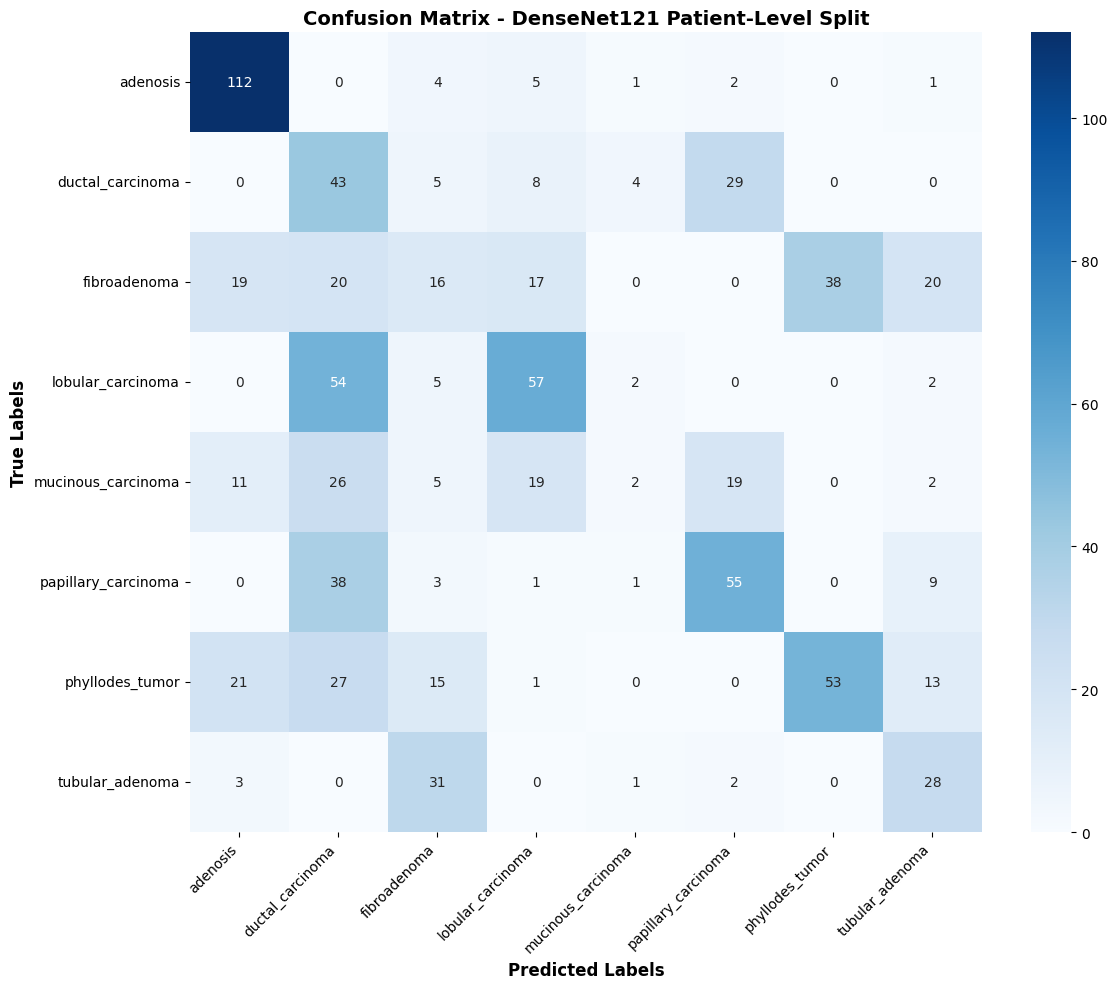


CLASSIFICATION REPORT

                     precision    recall  f1-score   support

           adenosis     0.6747    0.8960    0.7698       125
   ductal_carcinoma     0.2067    0.4831    0.2896        89
       fibroadenoma     0.1905    0.1231    0.1495       130
  lobular_carcinoma     0.5278    0.4750    0.5000       120
 mucinous_carcinoma     0.1818    0.0238    0.0421        84
papillary_carcinoma     0.5140    0.5140    0.5140       107
    phyllodes_tumor     0.5824    0.4077    0.4796       130
    tubular_adenoma     0.3733    0.4308    0.4000        65

           accuracy                         0.4306       850
          macro avg     0.4064    0.4192    0.3931       850
       weighted avg     0.4248    0.4306    0.4098       850



In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# EVALUATION AND PERFORMANCE METRICS
# ==========================================

print("Evaluating the DenseNet121 Ultimate model on the Test Set...\n")

# Ensure the model is in evaluation mode
model_dense.eval()

all_preds = []
all_labels = []

# Collect predictions on the test set without tracking gradients
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_dense(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get the class names from the test dataset
class_names = test_dataset.classes

# ------------------------------------------
# 1. GENERATE CONFUSION MATRIX
# ------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - DenseNet121 Patient-Level Split', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure in high resolution for the thesis
plt.savefig('/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/confusion_matrix_densenet.png', dpi=300)
plt.show()

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50 + "\n")

# ------------------------------------------
# 2. GENERATE CLASSIFICATION REPORT
# ------------------------------------------
# This will output Precision, Recall, and F1-Score for each specific class
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

The final experiment here is to try and get the ''ultimate version'' for a ViT

In [8]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. ARCHITECTURE SWAP: SWIN TRANSFORMER TINY
# ==========================================
print("Initializing Swin Transformer Tiny...")
# Swin-T is highly efficient and features hierarchical local attention
model_swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)

# Replace the head for 8 classes and add aggressive Dropout
num_ftrs_swin = model_swin.head.in_features
model_swin.head = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs_swin, 8)
)
model_swin = model_swin.to(device)

# ==========================================
# 2. OPTIMIZER: ADAMW (Crucial for Transformers)
# ==========================================
# Transformers require AdamW for proper weight decay decoupling
# We use differential learning rates here as well
backbone_params = [param for name, param in model_swin.named_parameters() if 'head' not in name]
classifier_params = model_swin.head.parameters()

optimizer_swin = optim.AdamW([
    {'params': backbone_params, 'lr': 2e-5},  # Very slow for the complex attention blocks
    {'params': classifier_params, 'lr': 5e-4} # Faster for the new head
], weight_decay=0.05) # AdamW requires higher weight decay (e.g., 0.05)

# ==========================================
# 3. LOSS FUNCTION & COSINE ANNEALING SCHEDULER
# ==========================================
targets = train_dataset_extreme.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion_swin = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

NUM_EPOCHS = 20
# Cosine Annealing smoothly decays the LR to a minimum value (eta_min)
scheduler_swin = optim.lr_scheduler.CosineAnnealingLR(optimizer_swin, T_max=NUM_EPOCHS, eta_min=1e-6)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print("Starting Ultimate Transformer Pipeline (Swin-T + AdamW + Cosine Annealing)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- TRAIN ---
    model_swin.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_extreme:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer_swin.zero_grad()
        outputs = model_swin(inputs)
        loss = criterion_swin(outputs, labels)

        loss.backward()
        # Gradient Clipping: Max norm of 1.0 is standard for Transformers
        torch.nn.utils.clip_grad_norm_(model_swin.parameters(), max_norm=1.0)
        optimizer_swin.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION ---
    model_swin.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model_swin(inputs)
            loss = criterion_swin(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    # Step the Cosine scheduler
    scheduler_swin.step()
    current_lr_backbone = optimizer_swin.param_groups[0]['lr']

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f} | "
          f"Backbone LR: {current_lr_backbone:.6f}")

print("\nTraining finished successfully.")
torch.save(model_swin.state_dict(), "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/swin_t_ultimate.pth")
print("Model saved as 'swin_t_ultimate.pth'")

Initializing Swin Transformer Tiny...
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 199MB/s] 


Starting Ultimate Transformer Pipeline (Swin-T + AdamW + Cosine Annealing)...

Epoch 1/20 (50.7s) -> Train Loss: 2.0008 | Train Acc: 0.2639 || Test Loss: 1.9554 | Test Acc: 0.2624 | Backbone LR: 0.000020
Epoch 2/20 (49.5s) -> Train Loss: 1.6357 | Train Acc: 0.4792 || Test Loss: 1.8153 | Test Acc: 0.3624 | Backbone LR: 0.000020
Epoch 3/20 (50.1s) -> Train Loss: 1.3672 | Train Acc: 0.6038 || Test Loss: 1.8263 | Test Acc: 0.3953 | Backbone LR: 0.000019
Epoch 4/20 (49.6s) -> Train Loss: 1.1911 | Train Acc: 0.7058 || Test Loss: 1.8663 | Test Acc: 0.4294 | Backbone LR: 0.000018
Epoch 5/20 (49.9s) -> Train Loss: 1.0787 | Train Acc: 0.7479 || Test Loss: 1.9497 | Test Acc: 0.3941 | Backbone LR: 0.000017
Epoch 6/20 (49.9s) -> Train Loss: 0.9852 | Train Acc: 0.7900 || Test Loss: 2.0219 | Test Acc: 0.4235 | Backbone LR: 0.000016
Epoch 7/20 (50.1s) -> Train Loss: 0.9240 | Train Acc: 0.8209 || Test Loss: 2.0029 | Test Acc: 0.4588 | Backbone LR: 0.000015
Epoch 8/20 (49.6s) -> Train Loss: 0.8645 | Tra

Graphical representation of the data

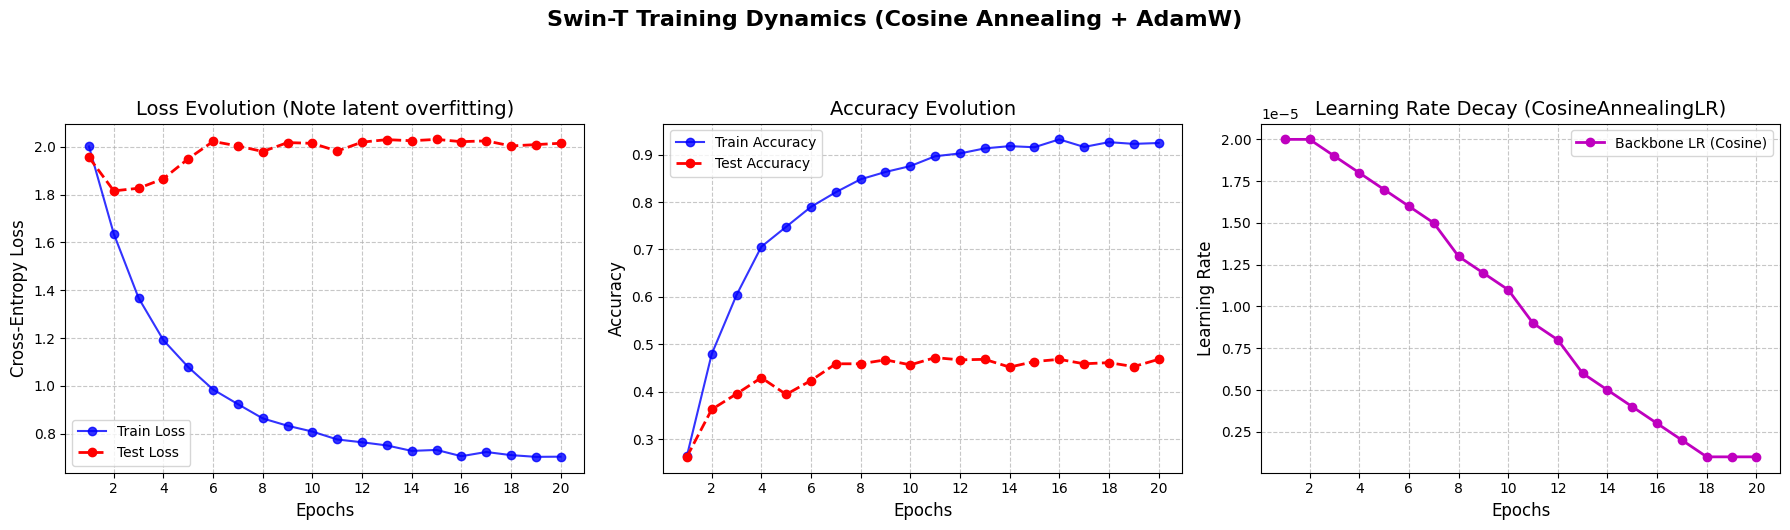

In [12]:
import matplotlib.pyplot as plt

# ==========================================
# DATA EXTRACTION (Swin-T Ultimate)
# ==========================================
epochs = range(1, 21)

train_loss = [2.0008, 1.6357, 1.3672, 1.1911, 1.0787, 0.9852, 0.9240, 0.8645, 0.8338, 0.8095, 0.7765, 0.7648, 0.7516, 0.7288, 0.7328, 0.7066, 0.7242, 0.7111, 0.7039, 0.7046]
test_loss = [1.9554, 1.8153, 1.8263, 1.8663, 1.9497, 2.0219, 2.0029, 1.9798, 2.0171, 2.0139, 1.9817, 2.0189, 2.0294, 2.0248, 2.0305, 2.0209, 2.0243, 2.0031, 2.0086, 2.0143]

train_acc = [0.2639, 0.4792, 0.6038, 0.7058, 0.7479, 0.7900, 0.8209, 0.8482, 0.8636, 0.8760, 0.8968, 0.9027, 0.9134, 0.9181, 0.9158, 0.9324, 0.9164, 0.9265, 0.9229, 0.9247]
test_acc = [0.2624, 0.3624, 0.3953, 0.4294, 0.3941, 0.4235, 0.4588, 0.4588, 0.4671, 0.4565, 0.4718, 0.4671, 0.4682, 0.4518, 0.4635, 0.4682, 0.4588, 0.4612, 0.4529, 0.4682]

# Extracted from your logs
lr_backbone = [2e-5, 2e-5, 1.9e-5, 1.8e-5, 1.7e-5, 1.6e-5, 1.5e-5, 1.3e-5, 1.2e-5, 1.1e-5, 9e-6, 8e-6, 6e-6, 5e-6, 4e-6, 3e-6, 2e-6, 1e-6, 1e-6, 1e-6]

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Swin-T Training Dynamics (Cosine Annealing + AdamW)', fontsize=16, fontweight='bold', y=1.05)

# 1. Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution (Note latent overfitting)', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(range(2, 21, 2))

# 2. Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xticks(range(2, 21, 2))

# 3. Learning Rate Plot
ax3.plot(epochs, lr_backbone, 'm-o', label='Backbone LR (Cosine)', linewidth=2) # Línea continua para mostrar la curva
ax3.set_title('Learning Rate Decay (CosineAnnealingLR)', fontsize=14)
ax3.set_xlabel('Epochs', fontsize=12)
ax3.set_ylabel('Learning Rate', fontsize=12)
ax3.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_xticks(range(2, 21, 2))

plt.tight_layout()

# Save for the thesis
plt.savefig('/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/training_curves_swin.png', dpi=300, bbox_inches='tight')
plt.show()

Evaluating the Swin-T Ultimate model on the Test Set...



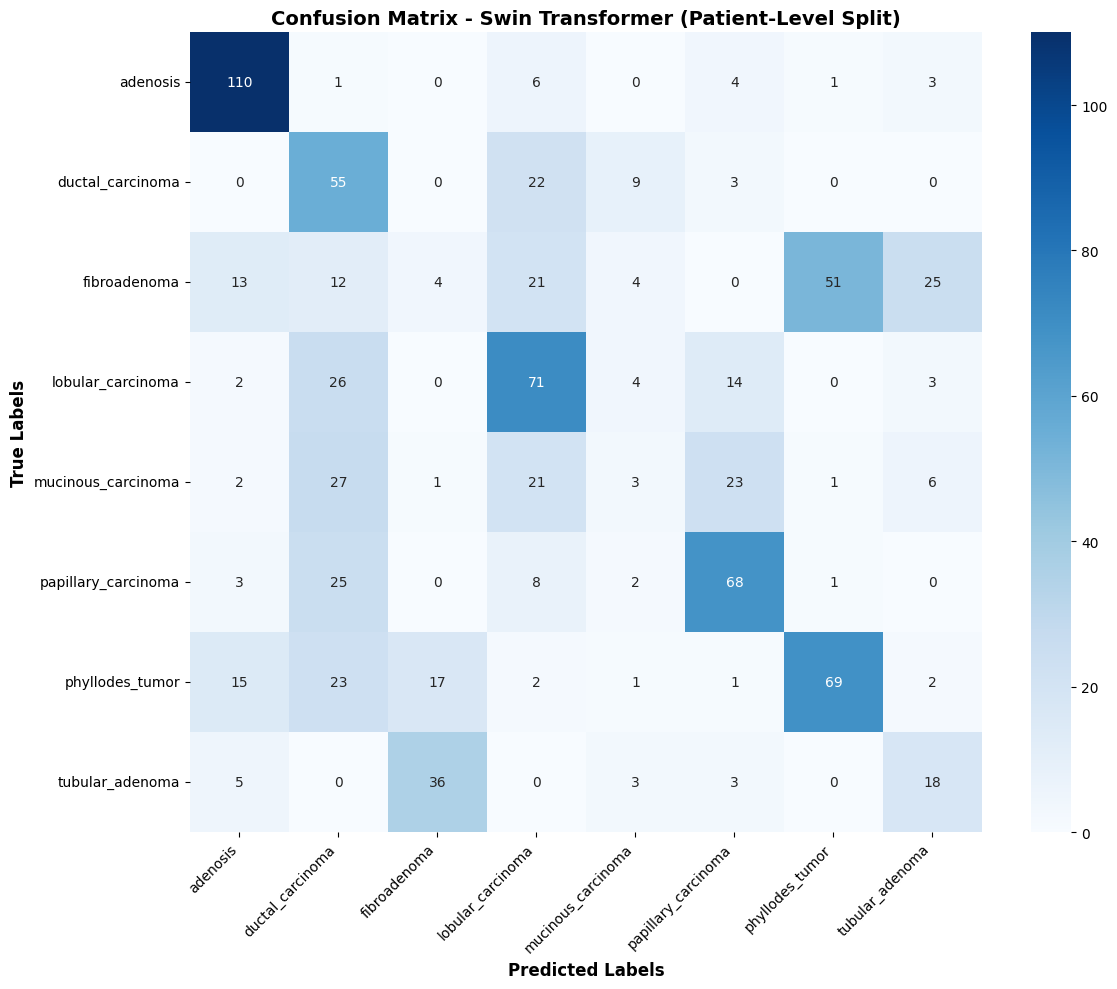


CLASSIFICATION REPORT - SWIN TRANSFORMER

                     precision    recall  f1-score   support

           adenosis     0.7333    0.8800    0.8000       125
   ductal_carcinoma     0.3254    0.6180    0.4264        89
       fibroadenoma     0.0690    0.0308    0.0426       130
  lobular_carcinoma     0.4702    0.5917    0.5240       120
 mucinous_carcinoma     0.1154    0.0357    0.0545        84
papillary_carcinoma     0.5862    0.6355    0.6099       107
    phyllodes_tumor     0.5610    0.5308    0.5455       130
    tubular_adenoma     0.3158    0.2769    0.2951        65

           accuracy                         0.4682       850
          macro avg     0.3970    0.4499    0.4122       850
       weighted avg     0.4140    0.4682    0.4309       850



In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# EVALUATION AND PERFORMANCE METRICS (SWIN-T)
# ==========================================

print("Evaluating the Swin-T Ultimate model on the Test Set...\n")

# Ensure the model is in evaluation mode
model_swin.eval()

all_preds = []
all_labels = []

# Collect predictions on the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_swin(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = test_dataset.classes

# ------------------------------------------
# 1. GENERATE CONFUSION MATRIX
# ------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Cambiado a naranja para distinguirlo del DenseNet en la memoria
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Swin Transformer (Patient-Level Split)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
plt.savefig('/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/confusion_matrix_swin.png', dpi=300)
plt.show()

print("\n" + "="*50)
print("CLASSIFICATION REPORT - SWIN TRANSFORMER")
print("="*50 + "\n")

# ------------------------------------------
# 2. GENERATE CLASSIFICATION REPORT
# ------------------------------------------
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

Visual environment where to try these experiments

In [13]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import torch.nn.functional as F

# ==========================================
# 1. SETUP & TRANSFORMATIONS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# PATH TO YOUR NEW 8-CLASS MODELS IN DRIVE
model_paths = {
    "DenseNet121 - CNN (Ultimate)": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/densenet121_ultimate.pth",
    "Swin Transformer - ViT (Ultimate)": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/swin_t_ultimate.pth"
}

# The exact 8 class names in alphabetical order
class_names = [
    'adenosis', 'ductal_carcinoma', 'fibroadenoma', 'lobular_carcinoma',
    'mucinous_carcinoma', 'papillary_carcinoma', 'phyllodes_tumor', 'tubular_adenoma'
]

# ==========================================
# 2. MODEL LOADING FUNCTION
# ==========================================
def load_model(model_name):
    if "DenseNet121" in model_name:
        model = models.densenet121(weights=None)
        num_ftrs = model.classifier.in_features
        # Must match exactly how we built it during training
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.6),
            nn.Linear(num_ftrs, 8)
        )
    else: # Swin Transformer
        model = models.swin_t(weights=None)
        num_ftrs_swin = model.head.in_features
        # Must match exactly how we built it during training
        model.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_ftrs_swin, 8)
        )

    model.load_state_dict(torch.load(model_paths[model_name], map_location=device))
    model = model.to(device)
    model.eval()
    return model

# ==========================================
# 3. PREDICTION PIPELINE
# ==========================================
def predict_image(image, model_choice):
    if image is None:
        return {"Please upload an image": 0.0}

    # Ensure image is in RGB format
    image = image.convert('RGB')
    model = load_model(model_choice)
    image_tensor = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    # Create dictionary mapping formatted class names to their probabilities
    result_dict = {class_names[i].replace('_', ' ').title(): float(probabilities[i]) for i in range(8)}

    return result_dict

# ==========================================
# 4. GRADIO INTERFACE LAUNCH
# ==========================================
interface = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="Upload a Histopathological Patch"),
        gr.Dropdown(choices=list(model_paths.keys()), value="Swin Transformer - ViT (Ultimate)", label="Select AI Architecture")
    ],
    outputs=gr.Label(num_top_classes=3, label="Top 3 Diagnoses"),
    title="Multi-Class Breast Cancer Classifier",
    description="Interactive deployment of state-of-the-art models (DenseNet121 vs Swin Transformer) trained under strict Patient-Level Split constraints for 8-class tumor identification.",
    theme="huggingface"
)

# Set share=True to generate a public link valid for 72 hours
interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:583: UserWarning: Cannot load huggingface. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/huggingface' (Request ID: Root=1-6a59ff88-2a3503f721312eac2486cd7f;24161ca3-1efb-4551-a9cb-985dbd3e86d5)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9b0031c432adb63c53.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
